In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm

# Set visualization style and suppress warnings
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 12})
warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)

# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Conference xD/Covid Dataset.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# Convert 'Yes'/'No' to 1/0 for all binary columns
binary_columns = df.columns.drop('covid_19', errors='ignore')
df[binary_columns] = df[binary_columns].replace({'Yes': 1, 'No': 0})

# Create comorbidity groups
df['comorbidity_group'] = 'No_comorbidities'
df.loc[(df['diabetes'] == 0) & (df['hyper_tension'] == 0), 'comorbidity_group'] = 'No_comorbidities'
df.loc[(df['diabetes'] == 1) & (df['hyper_tension'] == 0), 'comorbidity_group'] = 'Diabetes_only'
df.loc[(df['diabetes'] == 0) & (df['hyper_tension'] == 1), 'comorbidity_group'] = 'Hypertension_only'
df.loc[(df['diabetes'] == 1) & (df['hyper_tension'] == 1), 'comorbidity_group'] = 'Both'

# Make comorbidity_group categorical
df['comorbidity_group'] = pd.Categorical(
    df['comorbidity_group'],
    categories=['No_comorbidities', 'Diabetes_only', 'Hypertension_only', 'Both'],
    ordered=True
)

In [ ]:
# Define column groups
symptom_cols = ['breathing_problem', 'fever', 'dry_cough', 'sore_throat', 'running_nose',
                'headache', 'fatigue', 'gastrointestinal']
exposure_cols = ['abroad_travel', 'contact_with_covid_patient', 'attended_large_gathering',
                'visited_public_exposed_places', 'family_working_in_public_exposed_places']
other_comorbidities = ['asthma', 'chronic_lung_disease', 'heart_disease']

# Filter available columns
available_symptoms = [col for col in symptom_cols if col in df.columns]
available_exposure = [col for col in exposure_cols if col in df.columns]
available_other_comorbidities = [col for col in other_comorbidities if col in df.columns]

# Create aggregated features
df['respiratory_cluster'] = df[[col for col in available_symptoms if col in
                                ['breathing_problem', 'dry_cough', 'sore_throat', 'running_nose']]].sum(axis=1)
df['systemic_cluster'] = df[[col for col in available_symptoms if col in
                            ['fever', 'fatigue', 'headache', 'gastrointestinal']]].sum(axis=1)
df['exposure_score'] = df[available_exposure].sum(axis=1) if available_exposure else 0
df['other_comorbidity_count'] = df[available_other_comorbidities].sum(axis=1) if available_other_comorbidities else 0

# Advanced feature engineering
df['symptom_exposure_interaction'] = df['respiratory_cluster'] * df['exposure_score']
df['respiratory_to_systemic_ratio'] = df['respiratory_cluster'] / (df['systemic_cluster'] + 1)
df['symptom_to_comorbidity_ratio'] = (df['respiratory_cluster'] + df['systemic_cluster']) / (df['other_comorbidity_count'] + 1)
df['fever_squared'] = df['fever'] ** 2
df['breathing_squared'] = df['breathing_problem'] ** 2

<Figure size 1400x800 with 0 Axes>

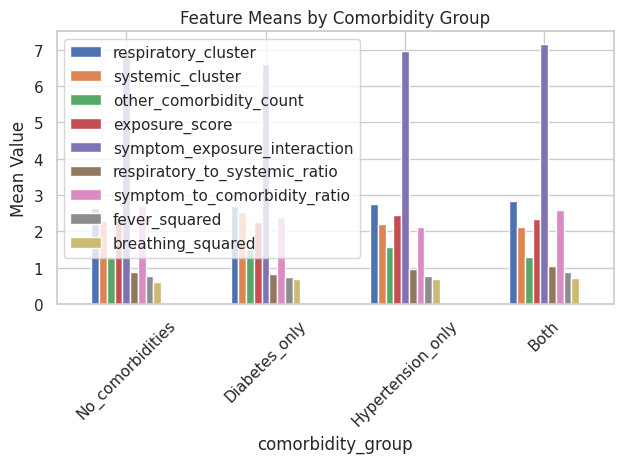

In [ ]:

# Analyze features by comorbidity group
feature_cols = ['respiratory_cluster', 'systemic_cluster', 'other_comorbidity_count',
                'exposure_score', 'symptom_exposure_interaction', 'respiratory_to_systemic_ratio',
                'symptom_to_comorbidity_ratio', 'fever_squared', 'breathing_squared']
feature_analysis = df.groupby('comorbidity_group')[feature_cols].mean()

# Visualize feature distributions
plt.figure(figsize=(14, 8))
feature_analysis.plot(kind='bar')
plt.title('Feature Means by Comorbidity Group')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

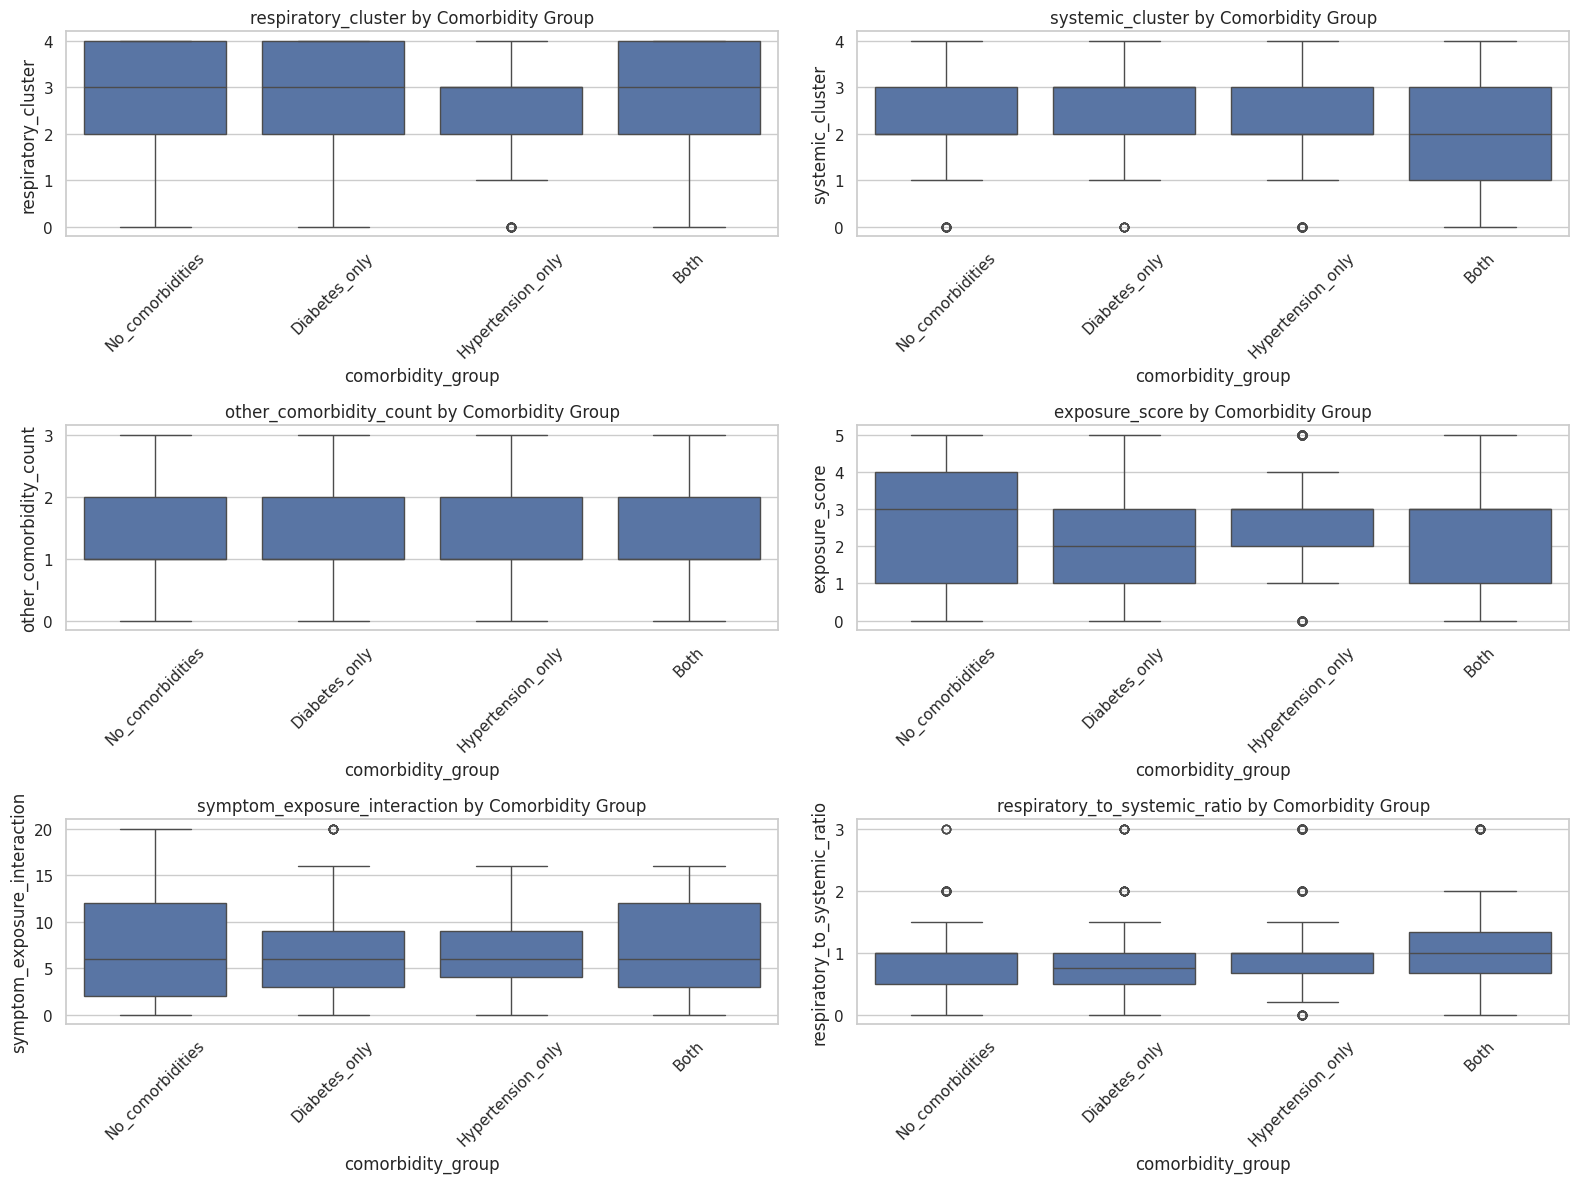

In [ ]:
# Box plots for feature distributions
plt.figure(figsize=(16, 12))
for i, feature in enumerate(feature_cols[:6]):  # Show first 6 features
    plt.subplot(3, 2, i+1)
    sns.boxplot(x='comorbidity_group', y=feature, data=df)
    plt.title(f'{feature} by Comorbidity Group')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Logistic Regression Analysis
# Create respiratory_severity column if it doesn't exist
if 'respiratory_severity' not in df.columns:
    respiratory_symptoms = ['breathing_problem', 'dry_cough', 'sore_throat', 'running_nose']
    # Ensure all respiratory symptom columns are numeric
    for col in respiratory_symptoms:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    df['respiratory_severity'] = df[respiratory_symptoms].sum(axis=1)

# Ensure diabetes and hyper_tension columns are numeric
df['diabetes'] = pd.to_numeric(df['diabetes'], errors='coerce').fillna(0).astype(int)
df['hyper_tension'] = pd.to_numeric(df['hyper_tension'], errors='coerce').fillna(0).astype(int)

# Prepare data for logistic regression
X_logit = df[['diabetes', 'hyper_tension']].copy()
X_logit['interaction'] = df['diabetes'] * df['hyper_tension']  # Synergy term
X_logit = sm.add_constant(X_logit)  # Add intercept
y_logit = (df['respiratory_severity'] >= 2).astype(int)  # Binary outcome

# Convert all data to numeric to avoid dtype issues
X_logit = X_logit.apply(pd.to_numeric, errors='coerce').fillna(0)
y_logit = pd.to_numeric(y_logit, errors='coerce').fillna(0).astype(int)

# Fit model
try:
    logit_model = sm.Logit(y_logit, X_logit).fit()
    print(logit_model.summary())

    # Calculate odds ratios
    odds_ratios = pd.DataFrame({
        'OR': np.exp(logit_model.params),
        'CI_lower': np.exp(logit_model.conf_int()[0]),
        'CI_upper': np.exp(logit_model.conf_int()[1])
    })
    print("\nOdds Ratios:\n", odds_ratios)

    # High-Risk Subgroup Analysis
    high_risk = df[(df['respiratory_severity'] >= 2) &
                   (df['comorbidity_group'].isin(['Diabetes_only', 'Hypertension_only', 'Both']))]
    print("\nHigh-Risk Subgroup Characteristics:")
    print(f"Total high-risk patients: {len(high_risk)}")
    print(f"Percentage with diabetes: {high_risk['diabetes'].mean()*100:.1f}%")
    print(f"Percentage with hypertension: {high_risk['hyper_tension'].mean()*100:.1f}%")
    print(f"Percentage with both: {(high_risk['diabetes'] & high_risk['hyper_tension']).mean()*100:.1f}%")
except Exception as e:
    print(f"Error fitting logistic regression model: {e}")
    print("Checking data types:")
    print(X_logit.dtypes)
    print(y_logit.dtype)

Optimization terminated successfully.
         Current function value: 0.402099
         Iterations 6
                            Logit Regression Results                            
Dep. Variable:     respiratory_severity   No. Observations:                 5434
Model:                            Logit   Df Residuals:                     5430
Method:                             MLE   Df Model:                            3
Date:                  Fri, 15 Aug 2025   Pseudo R-squ.:                0.003150
Time:                          14:03:01   Log-Likelihood:                -2185.0
converged:                         True   LL-Null:                       -2191.9
Covariance Type:              nonrobust   LLR p-value:                  0.003175
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.7574      0.073     24.182      0.000       1.615       1.900
diab

Train size: 3803
Validation size: 815
Test size: 816

Best k found: 19 with validation accuracy: 0.36

Final Test Accuracy: 0.3247549019607843

Classification Report:
                    precision    recall  f1-score   support

             Both       0.31      0.52      0.39       199
    Diabetes_only       0.29      0.23      0.26       189
Hypertension_only       0.29      0.17      0.22       201
 No_comorbidities       0.38      0.37      0.37       227

         accuracy                           0.32       816
        macro avg       0.32      0.32      0.31       816
     weighted avg       0.32      0.32      0.31       816



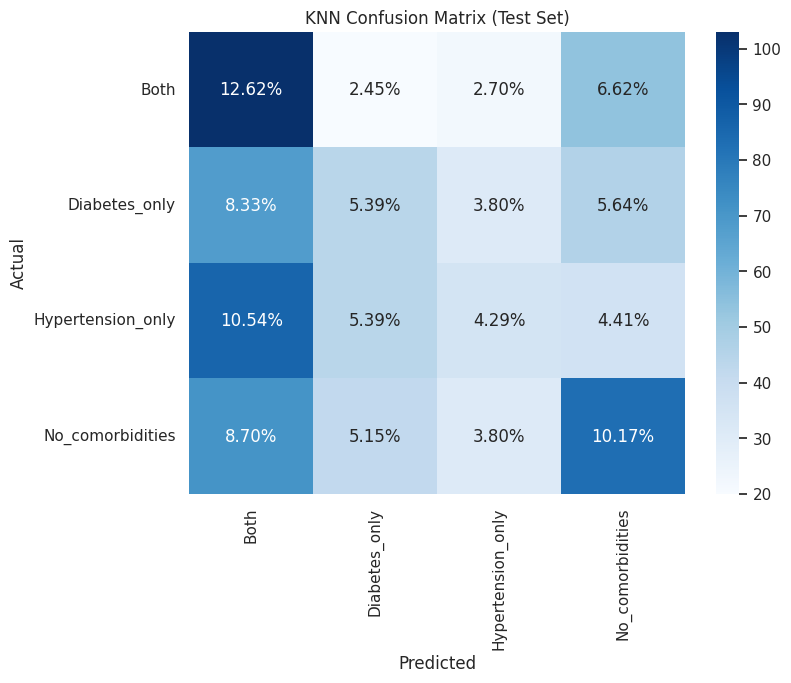

In [ ]:
# Prepare features and target
X_knn = df[['respiratory_cluster', 'systemic_cluster']]
y_knn = df['comorbidity_group']

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X_knn, y_knn, test_size=0.30, stratify=y_knn, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# Find best k using validation set
best_k = None
best_val_acc = 0
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, val_pred)
    if acc > best_val_acc:
        best_val_acc = acc
        best_k = k

print(f"\nBest k found: {best_k} with validation accuracy: {best_val_acc:.2f}")

# Retrain with best k on train+val
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_final, y_train_final)
y_test_pred = final_knn.predict(X_test)

# Final evaluation
print("\nFinal Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion matrix with percentages
cm = confusion_matrix(y_test, y_test_pred, labels=final_knn.classes_)
cm_sum = np.sum(cm)  # Total number of instances
cm_percentage = (cm / cm_sum * 100).round(2)  # Convert to percentages, rounded to 2 decimals
annot = np.array([f'{val:.2f}%' for val in cm_percentage.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=final_knn.classes_, yticklabels=final_knn.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix (Test Set)")
plt.show()

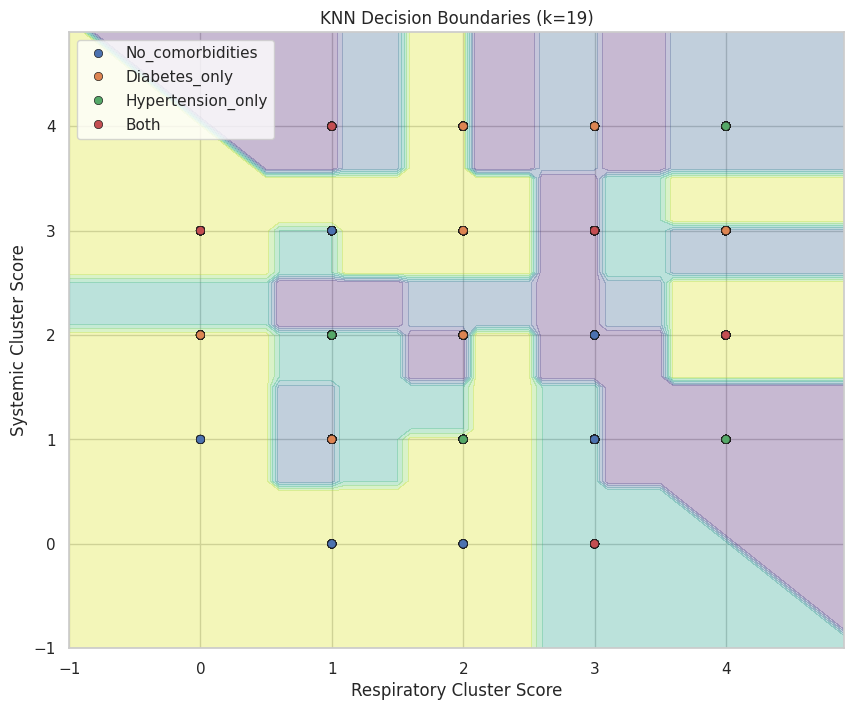

In [ ]:
# Decision boundary
h = 0.1
x_min, x_max = X_knn['respiratory_cluster'].min() - 1, X_knn['respiratory_cluster'].max() + 1
y_min, y_max = X_knn['systemic_cluster'].min() - 1, X_knn['systemic_cluster'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = final_knn.predict(np.c_[xx.ravel(), yy.ravel()])
class_mapping = {label: idx for idx, label in enumerate(final_knn.classes_)}
Z_numeric = np.array([class_mapping[label] for label in Z]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='viridis')
sns.scatterplot(x='respiratory_cluster', y='systemic_cluster',
                hue='comorbidity_group', data=df, edgecolor='k')
plt.title(f'KNN Decision Boundaries (k={best_k})')
plt.xlabel('Respiratory Cluster Score')
plt.ylabel('Systemic Cluster Score')
plt.legend()
plt.show()

Train size: 3803
Validation size: 815
Test size: 816

Validation Accuracy: 0.30

Final Test Accuracy: 0.2806372549019608

Classification Report:
                    precision    recall  f1-score   support

             Both       0.34      0.30      0.31       199
    Diabetes_only       0.25      0.32      0.28       189
Hypertension_only       0.00      0.00      0.00       201
 No_comorbidities       0.28      0.48      0.35       227

         accuracy                           0.28       816
        macro avg       0.22      0.27      0.24       816
     weighted avg       0.22      0.28      0.24       816



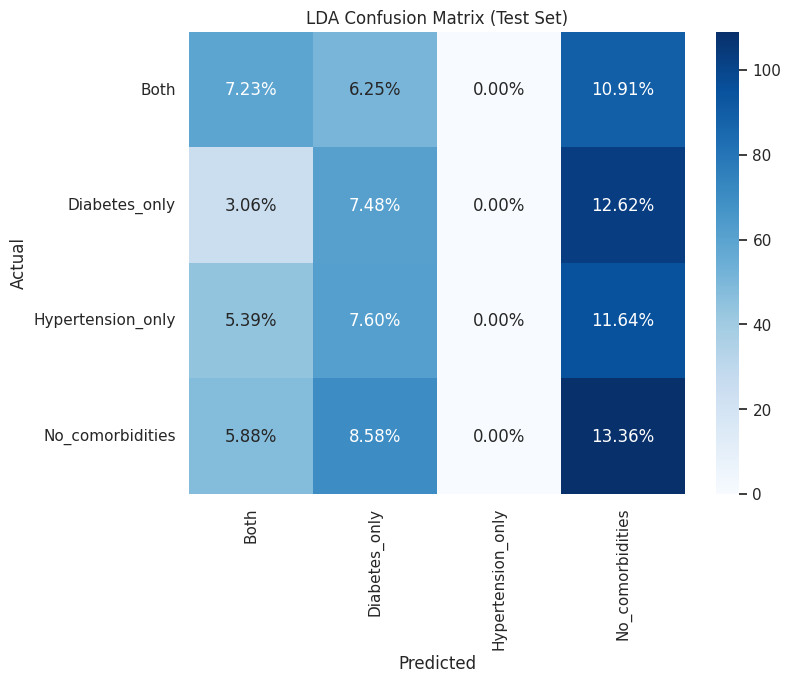

In [ ]:
# Prepare features and target
X_lda = df[['respiratory_cluster', 'systemic_cluster']]
y_lda = df['comorbidity_group']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lda)
X_lda = pd.DataFrame(X_scaled, columns=X_lda.columns)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X_lda, y_lda, test_size=0.30, stratify=y_lda, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Evaluate on validation set
y_val_pred = lda.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.2f}")

# Retrain on train+val
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])
final_lda = LinearDiscriminantAnalysis()
final_lda.fit(X_train_final, y_train_final)
y_test_pred = final_lda.predict(X_test)

# Final evaluation
print("\nFinal Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion matrix with percentages
cm = confusion_matrix(y_test, y_test_pred, labels=final_lda.classes_)
cm_sum = np.sum(cm)  # Total number of instances
cm_percentage = (cm / cm_sum * 100).round(2)  # Convert to percentages, rounded to 2 decimals
annot = np.array([f'{val:.2f}%' for val in cm_percentage.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=final_lda.classes_, yticklabels=final_lda.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LDA Confusion Matrix (Test Set)")
plt.show()

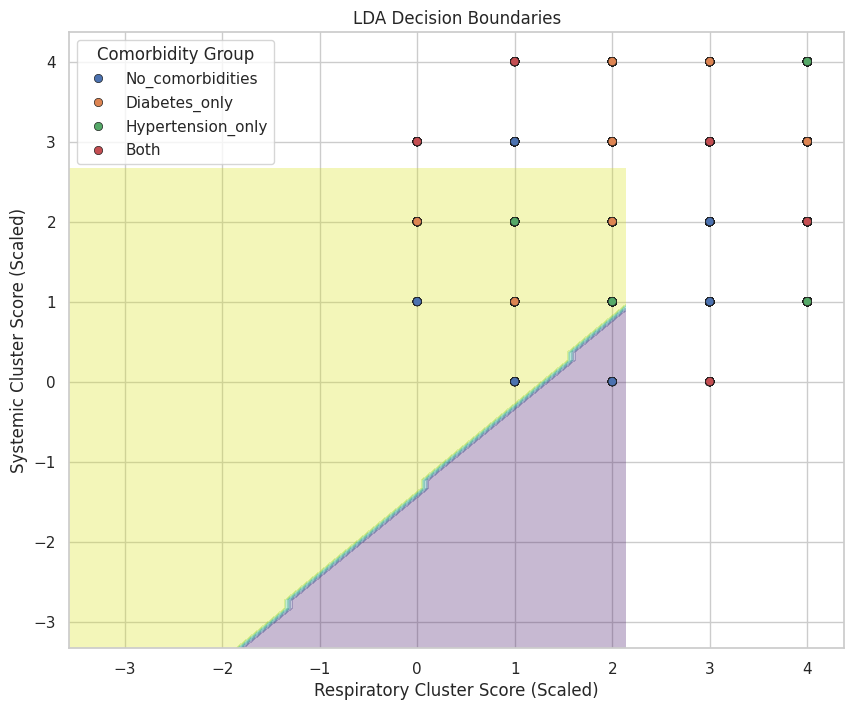

In [ ]:
# Decision boundary
h = 0.1
x_min, x_max = X_lda['respiratory_cluster'].min() - 1, X_lda['respiratory_cluster'].max() + 1
y_min, y_max = X_lda['systemic_cluster'].min() - 1, X_lda['systemic_cluster'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = final_lda.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
class_mapping = {label: idx for idx, label in enumerate(final_lda.classes_)}
Z_numeric = np.array([class_mapping[label] for label in Z]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_numeric, alpha=0.3, cmap='viridis')
sns.scatterplot(x='respiratory_cluster', y='systemic_cluster',
                hue='comorbidity_group', data=df, edgecolor='k')
plt.title('LDA Decision Boundaries')
plt.xlabel('Respiratory Cluster Score (Scaled)')
plt.ylabel('Systemic Cluster Score (Scaled)')
plt.legend(title='Comorbidity Group')
plt.show()

# RF


Validation Accuracy: 0.97

Validation Classification Report:
                    precision    recall  f1-score   support

             Both       0.99      0.96      0.98       199
    Diabetes_only       0.95      0.97      0.96       190
Hypertension_only       0.94      0.99      0.97       200
 No_comorbidities       1.00      0.96      0.98       226

         accuracy                           0.97       815
        macro avg       0.97      0.97      0.97       815
     weighted avg       0.97      0.97      0.97       815


Final Test Accuracy: 0.97

Final Classification Report:
                    precision    recall  f1-score   support

             Both       0.99      0.96      0.98       199
    Diabetes_only       0.99      0.94      0.96       189
Hypertension_only       0.92      1.00      0.96       201
 No_comorbidities       1.00      0.98      0.99       227

         accuracy                           0.97       816
        macro avg       0.97      0.97      0.97

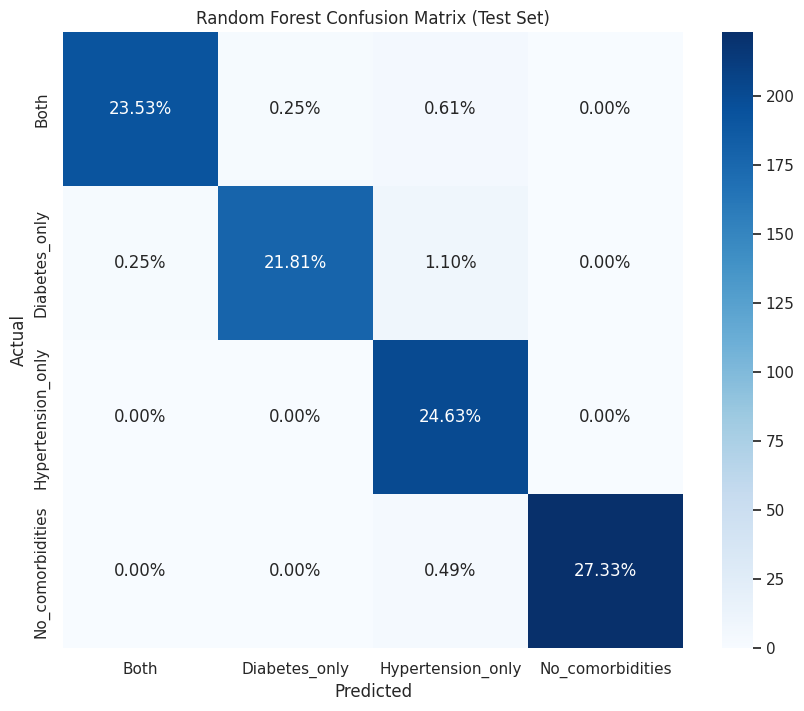

In [ ]:
# Prepare features and target
feature_cols = (available_symptoms + available_exposure +
                available_other_comorbidities +
                ['respiratory_cluster', 'systemic_cluster', 'exposure_score', 'other_comorbidity_count',
                 'symptom_exposure_interaction', 'respiratory_to_systemic_ratio',
                 'symptom_to_comorbidity_ratio', 'fever_squared', 'breathing_squared'])
X_rf = df[feature_cols]
y_rf = df['comorbidity_group']

# Feature selection
selector = SelectKBest(score_func=chi2, k=min(15, X_rf.shape[1]))
X_selected = selector.fit_transform(X_rf, y_rf)
selected_features = X_rf.columns[selector.get_support()].tolist()
X_rf = pd.DataFrame(X_selected, columns=selected_features)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X_rf, y_rf, test_size=0.30, stratify=y_rf, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# Evaluate
y_val_pred = rf.predict(X_val)
print(f"\nValidation Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
print("\nValidation Classification Report:\n", classification_report(y_val, y_val_pred, zero_division=0))

# Final evaluation
y_test_pred = rf.predict(X_test)
print(f"\nFinal Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nFinal Classification Report:\n", classification_report(y_test, y_test_pred, zero_division=0))

# Confusion matrix with percentages
cm = confusion_matrix(y_test, y_test_pred, labels=rf.classes_)
cm_sum = np.sum(cm)  # Total number of instances
cm_percentage = (cm / cm_sum * 100).round(2)  # Convert to percentages, rounded to 2 decimals
annot = np.array([f'{val:.2f}%' for val in cm_percentage.flatten()]).reshape(cm.shape)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

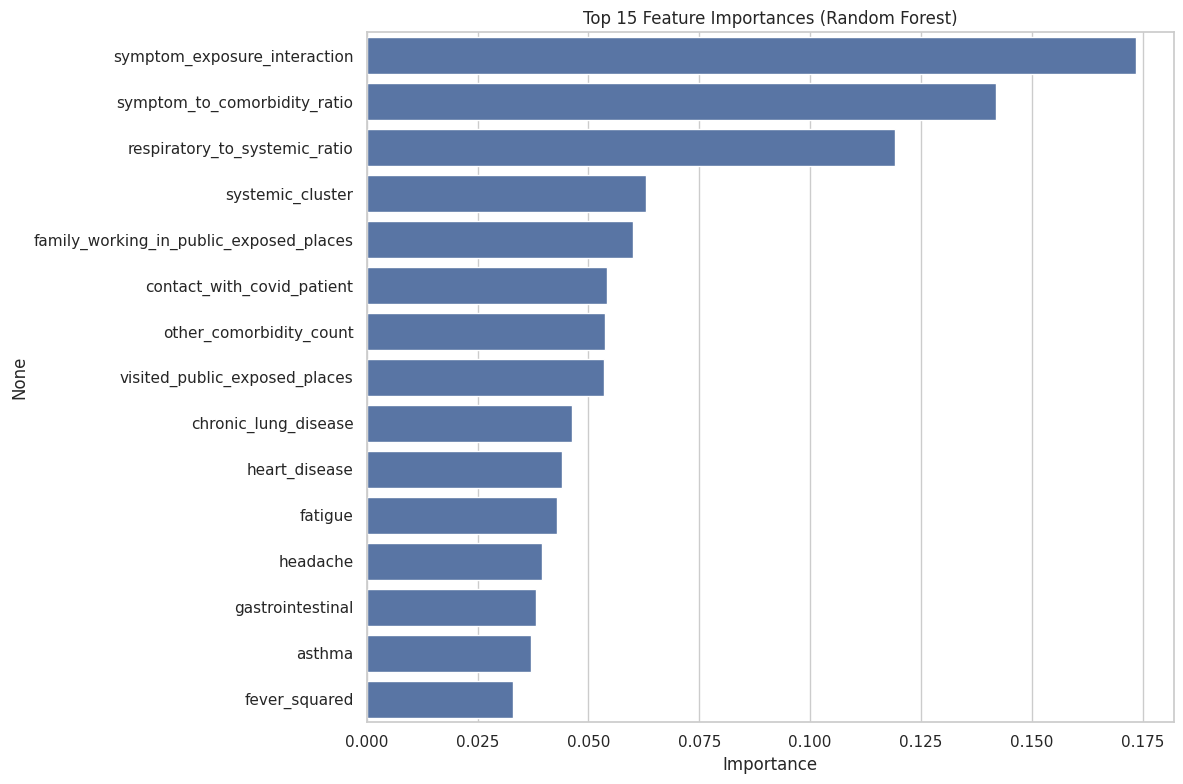

In [ ]:
# Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X_rf.columns)
plt.figure(figsize=(12, 8))
top_features = feature_importances.sort_values(ascending=False).head(15)
sns.barplot(x=top_features, y=top_features.index)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Cell 13: Advanced Ensemble Models and Hyperparameter Tuning


Model Comparison:
                       accuracy  macro_f1  weighted_f1
Neural Network         0.979167  0.978523     0.979186
Random Forest (Tuned)  0.973039  0.972531     0.973226
Extra Trees            0.973039  0.972482     0.973184
SVM                    0.881127  0.880018     0.881134
Gradient Boosting      0.738971  0.739092     0.739056
Logistic Regression    0.398284  0.394071     0.390586

Updated Model Comparison (with Ensembles):
                       accuracy  macro_f1  weighted_f1
Neural Network         0.979167  0.978523     0.979186
Random Forest (Tuned)  0.973039  0.972531     0.973226
Voting Classifier      0.973039  0.972531     0.973226
Extra Trees            0.973039  0.972482     0.973184
Stacking Classifier    0.973039  0.972482     0.973184
SVM                    0.881127  0.880018     0.881134
Gradient Boosting      0.738971  0.739092     0.739056
Logistic Regression    0.398284  0.394071     0.390586

Best Model: Neural Network

Final Model Evaluation:
Accu

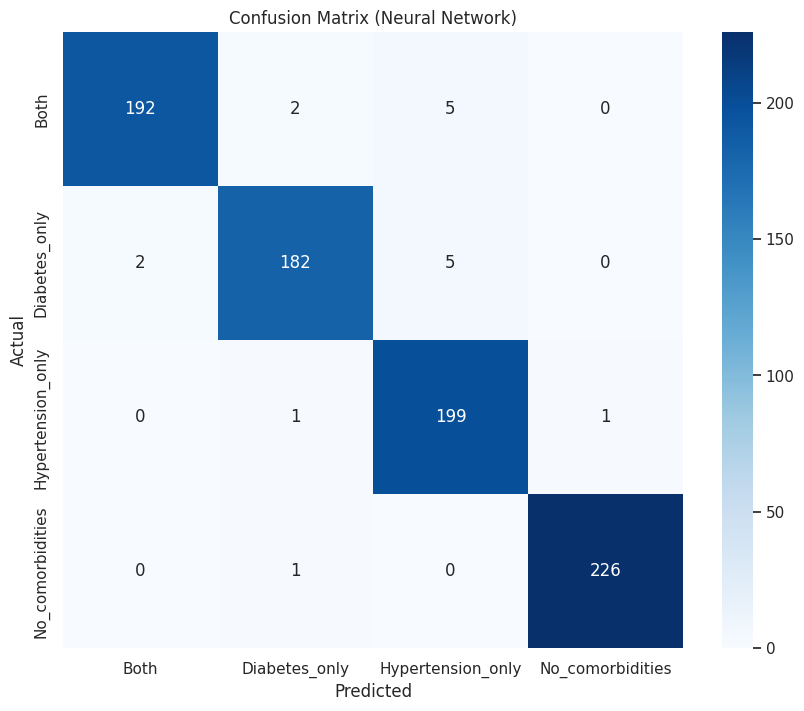


Misclassification Analysis:
Total misclassified: 17 out of 816 (2.1%)

Class-wise misclassification rates:
Both: 3.5% misclassified
Diabetes_only: 3.7% misclassified
Hypertension_only: 1.0% misclassified
No_comorbidities: 0.4% misclassified


In [ ]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_resampled, y_train_resampled)
best_rf = grid_search.best_estimator_

# Define models to test
models = {
    'Random Forest (Tuned)': best_rf,
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# Evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    results[name] = {
        'accuracy': accuracy,
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score']
    }

# Compare results
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.sort_values('accuracy', ascending=False))

# Create ensemble models
best_models = [
    ('rf', best_rf),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(random_state=42))
]

voting_clf = VotingClassifier(estimators=best_models, voting='soft')
voting_clf.fit(X_train_resampled, y_train_resampled)
y_pred_voting = voting_clf.predict(X_test)
voting_accuracy = accuracy_score(y_test, y_pred_voting)

stacking_clf = StackingClassifier(
    estimators=best_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42)
)
stacking_clf.fit(X_train_resampled, y_train_resampled)
y_pred_stacking = stacking_clf.predict(X_test)
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)

# Add ensemble results to comparison
results_df.loc['Voting Classifier'] = {
    'accuracy': voting_accuracy,
    'macro_f1': classification_report(y_test, y_pred_voting, output_dict=True, zero_division=0)['macro avg']['f1-score'],
    'weighted_f1': classification_report(y_test, y_pred_voting, output_dict=True, zero_division=0)['weighted avg']['f1-score']
}

results_df.loc['Stacking Classifier'] = {
    'accuracy': stacking_accuracy,
    'macro_f1': classification_report(y_test, y_pred_stacking, output_dict=True, zero_division=0)['macro avg']['f1-score'],
    'weighted_f1': classification_report(y_test, y_pred_stacking, output_dict=True, zero_division=0)['weighted avg']['f1-score']
}

print("\nUpdated Model Comparison (with Ensembles):")
print(results_df.sort_values('accuracy', ascending=False))

# Select best model
best_model_name = results_df['accuracy'].idxmax()
if best_model_name == 'Random Forest (Tuned)':
    final_model = best_rf
elif best_model_name == 'Voting Classifier':
    final_model = voting_clf
elif best_model_name == 'Stacking Classifier':
    final_model = stacking_clf
else:
    final_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")

# Final evaluation
y_pred_final = final_model.predict(X_test)
print("\nFinal Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.2f}")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Cross-validation
cv_scores = cross_val_score(final_model, X_rf, y_rf, cv=10, scoring='accuracy')
print(f"\n10-Fold Cross-Validation Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

# Feature importance for best model (if available)
if hasattr(final_model, 'feature_importances_'):
    feature_importances = pd.Series(final_model.feature_importances_, index=X_rf.columns)
    plt.figure(figsize=(12, 8))
    top_features = feature_importances.sort_values(ascending=False).head(15)
    sns.barplot(x=top_features, y=top_features.index)
    plt.title(f'Top 15 Feature Importances ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_, yticklabels=final_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

# Error analysis
misclassified = X_test[y_test != y_pred_final]
misclassified_rate = len(misclassified) / len(X_test) * 100
print(f"\nMisclassification Analysis:")
print(f"Total misclassified: {len(misclassified)} out of {len(X_test)} ({misclassified_rate:.1f}%)")
print("\nClass-wise misclassification rates:")
for i, class_name in enumerate(final_model.classes_):
    total = cm[i, :].sum()
    correct = cm[i, i]
    misclassified_rate = (total - correct) / total * 100
    print(f"{class_name}: {misclassified_rate:.1f}% misclassified")

# # Save results
# results_df.to_csv('model_comparison_results.csv')
# feature_importances.to_csv('feature_importances.csv')